In [ ]:
# Require installations.
!pip install scipy
!pip install qiskit==1.1.0
!pip install qiskit qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pennylane==0.35.0
!pip install openfermionpyscf
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.3/343.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 432.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 8.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pennylane-lightning to determine which version is compatible with other requirements. Th

In [ ]:
# from qiskit import QuantumCircuit
# from qiskit import transpile
# #from qiskit_ionq import IonQProvider
# #from qiskit.providers.jobstatus import JobStatus
# from qiskit_ibm_runtime import QiskitRuntimeService, Session, Sampler
# import time
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
#from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import QiskitRuntimeService



In [ ]:
service = QiskitRuntimeService(channel="ibm_quantum", token="")
backend = service.least_busy(simulator=False, operational=True)


In [ ]:
circuit = QuantumCircuit(6,6)
circuit.h(0)
circuit.x(1)
circuit.h(2) # I also change the order ZH
circuit.z(2)
circuit.barrier()
circuit.h([4])
#add_cswap(circuit, control_qubit=4, target_qubit1=3, target_qubit2=1)
circuit.cswap(4, 3, 1)
#add_cswap(circuit, control_qubit=4, target_qubit1=2, target_qubit2=0)
circuit.cswap(4, 2, 0)
circuit.h([4])
circuit.barrier()
circuit.h(5)
#add_cswap(circuit, control_qubit=5, target_qubit1=3, target_qubit2=1)
circuit.cswap(5,2,0)
circuit.h(5)
circuit.barrier()
circuit.measure([0,1,2,3,4,5], [0,1,2,3,4,5])
#decomposed_circuit=circuit.decompose().decompose().decompose()
# compiled_circuit=transpile(decomposed_circuit,qpu)
print(circuit.draw())
# depth=compiled_circuit.depth()
# print(depth)
# print(decomposed_circuit)
# print(compiled_circuit.draw())


     ┌───┐      ░                  ░               ░ ┌─┐               
q_0: ┤ H ├──────░──────────X───────░───────X───────░─┤M├───────────────
     ├───┤      ░          │       ░       │       ░ └╥┘┌─┐            
q_1: ┤ X ├──────░───────X──┼───────░───────┼───────░──╫─┤M├────────────
     ├───┤┌───┐ ░       │  │       ░       │       ░  ║ └╥┘┌─┐         
q_2: ┤ H ├┤ Z ├─░───────┼──X───────░───────X───────░──╫──╫─┤M├─────────
     └───┘└───┘ ░       │  │       ░       │       ░  ║  ║ └╥┘┌─┐      
q_3: ───────────░───────X──┼───────░───────┼───────░──╫──╫──╫─┤M├──────
                ░ ┌───┐ │  │ ┌───┐ ░       │       ░  ║  ║  ║ └╥┘┌─┐   
q_4: ───────────░─┤ H ├─■──■─┤ H ├─░───────┼───────░──╫──╫──╫──╫─┤M├───
                ░ └───┘      └───┘ ░ ┌───┐ │ ┌───┐ ░  ║  ║  ║  ║ └╥┘┌─┐
q_5: ───────────░──────────────────░─┤ H ├─■─┤ H ├─░──╫──╫──╫──╫──╫─┤M├
                ░                  ░ └───┘   └───┘ ░  ║  ║  ║  ║  ║ └╥┘
c: 6/═════════════════════════════════════════════════╩══╩══╩══╩

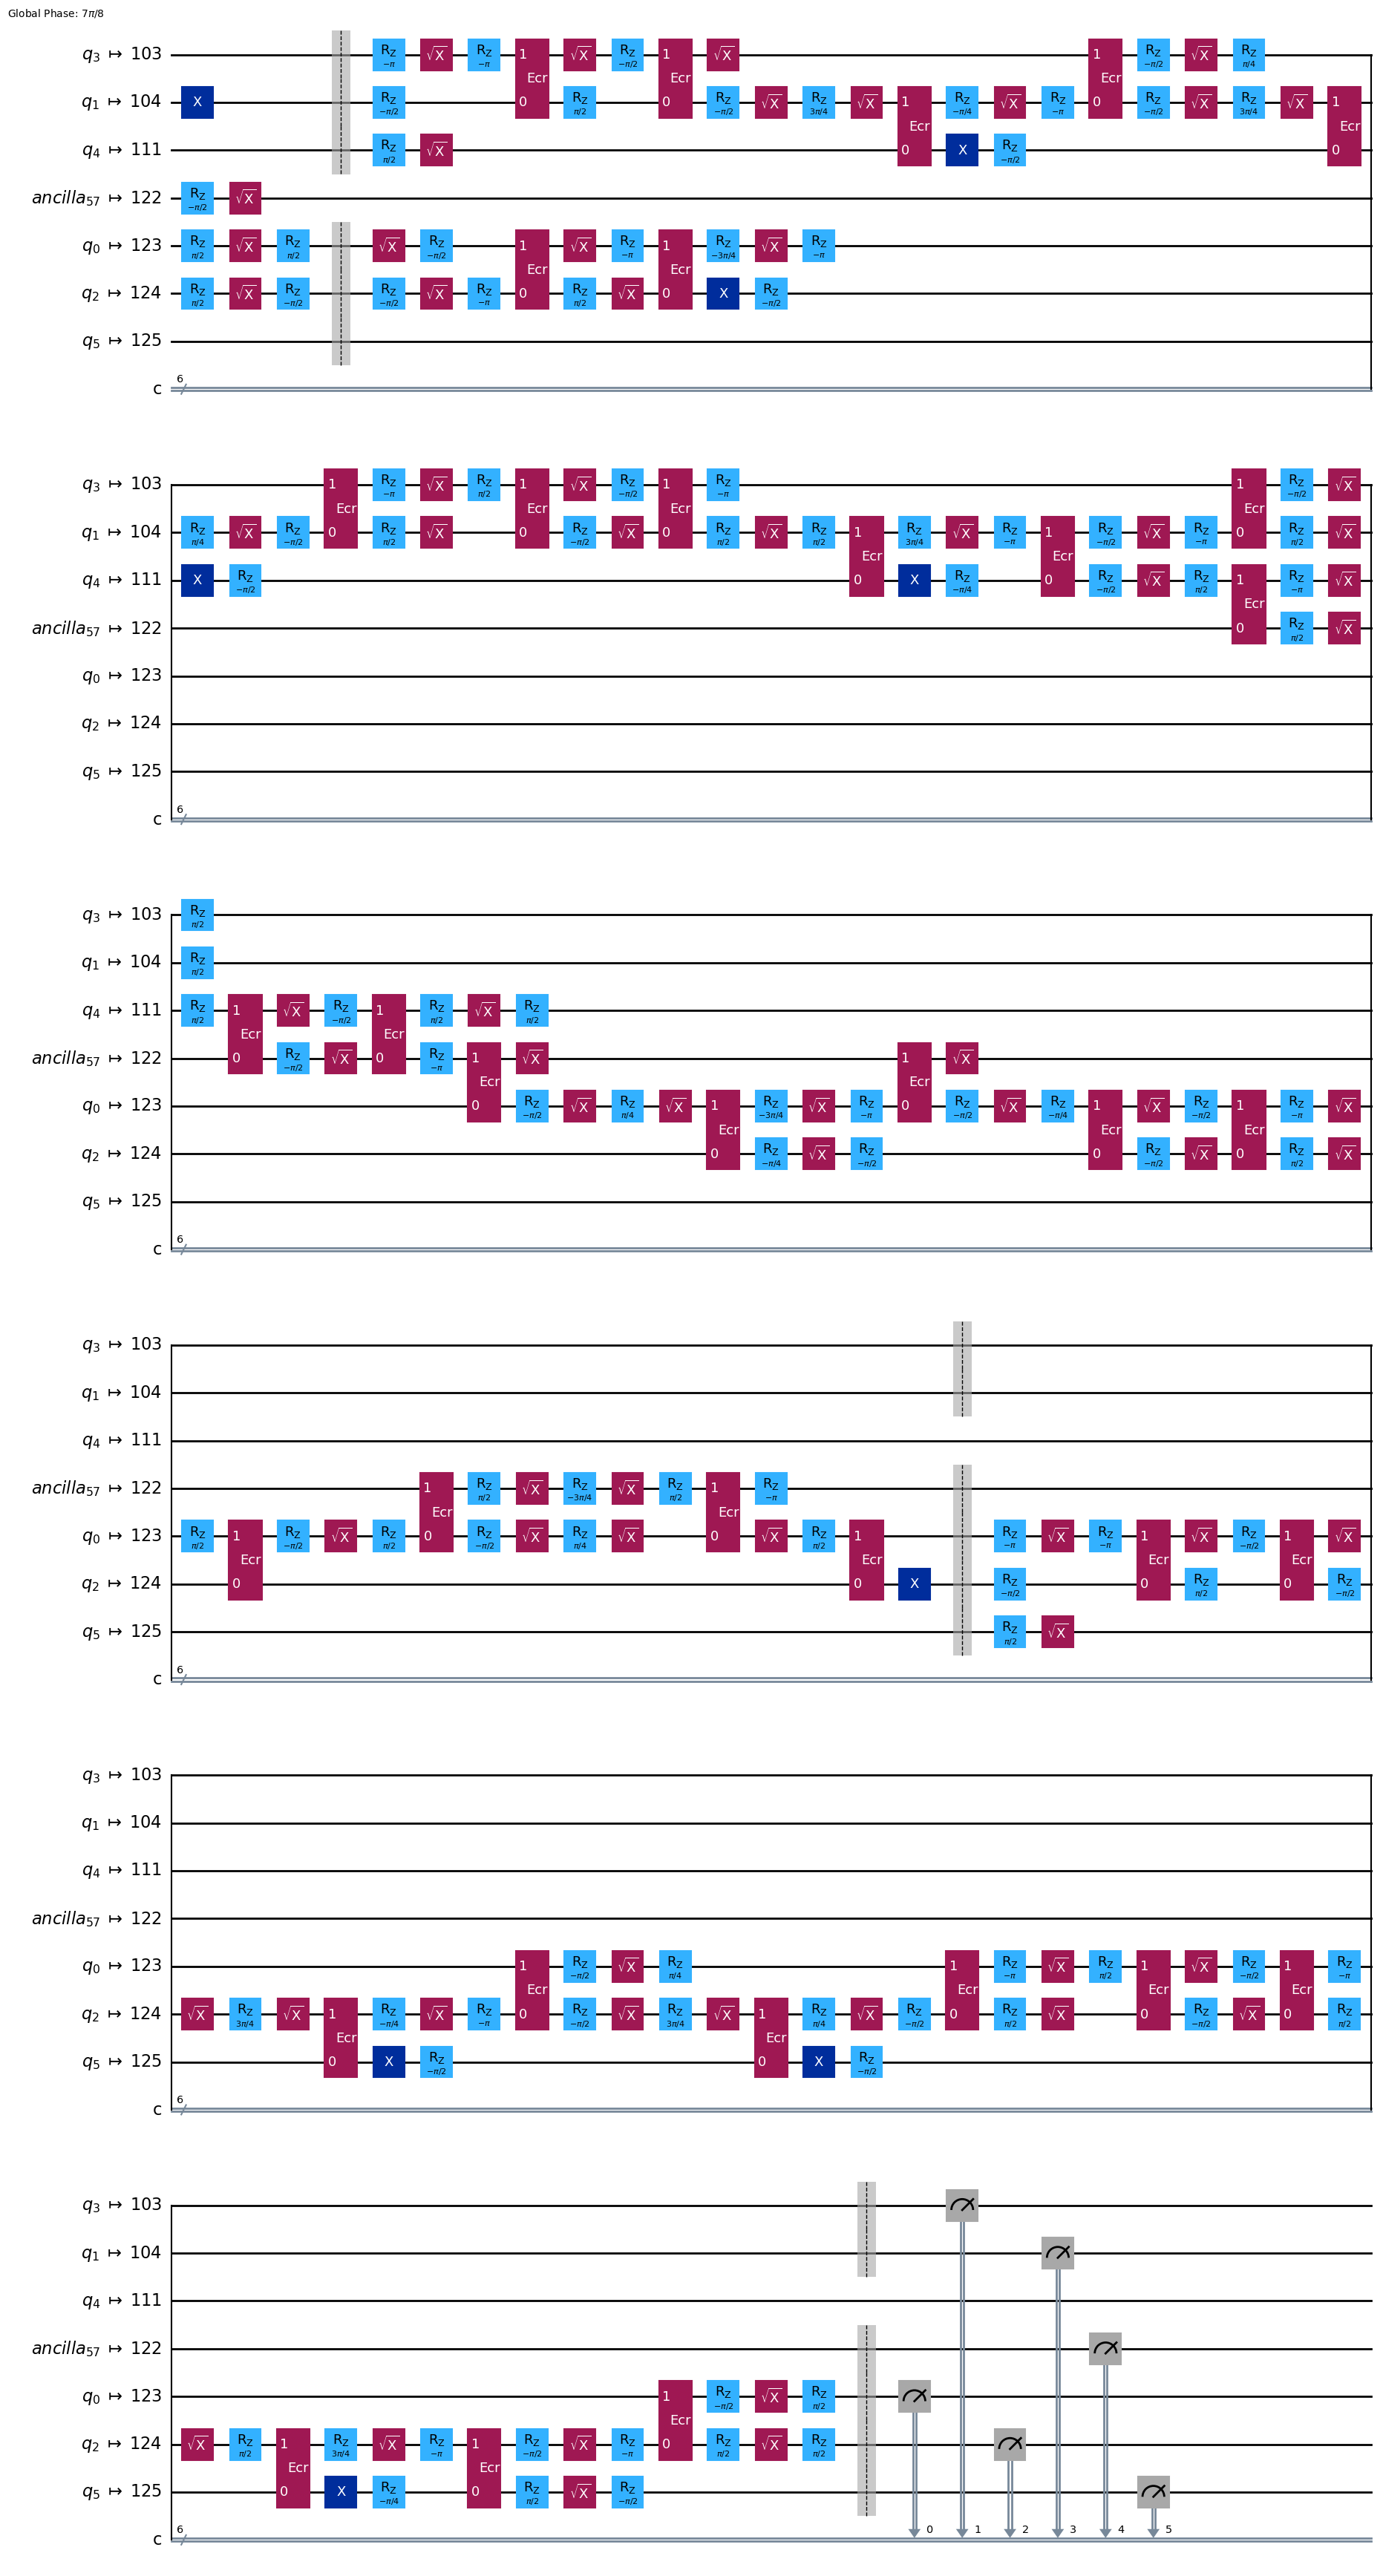

In [ ]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
#isa_circuit = pm.run(decomposed_circuit)
isa_circuit = pm.run(circuit)


isa_circuit.draw('mpl', idle_wires=False)

In [ ]:

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
# job = sampler.run([isa_circuit])
job = sampler.run([isa_circuit],shots=10000)

print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")



>>> Job ID: cvs21cdxx5ag008hb5k0
>>> Job Status: QUEUED


In [ ]:
#get the result
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='',
    token=''
)
job = service.job('cvs21cdxx5ag008hb5k0')
job_result = job.result()
result=job_result
print(result)
pub_result = job_result[0].data.c.get_counts()
print(pub_result)
# To get counts for a particular pub result, use
#
# pub_result = job_result[<idx>].data.<classical register>.get_counts()
#
# where <idx> is the index of the pub and <classical register> is the name of the classical register.
# You can use circuit.cregs to find the name of the classical registers.


PrimitiveResult([PubResult(data=DataBin(c=BitArray(<shape=(), num_shots=10000, num_bits=6>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([SliceSpan(<start='2024-09-24 02:15:18', stop='2024-09-24 02:15:57', size=10000>)])}, 'version': 2})
{'101001': 553, '111000': 122, '001100': 217, '111101': 136, '010011': 274, '011001': 247, '000111': 667, '001000': 217, '011101': 726, '001101': 228, '101100': 835, '001010': 50, '110110': 871, '011111': 23, '101101': 43, '100110': 231, '111001': 143, '010110': 206, '111011': 23, '000000': 61, '010010': 187, '100010': 121, '001001': 189, '000100': 28, '100100': 56, '110111': 89, '100111': 132, '011100': 179, '010111': 270, '010100': 26, '000110': 113, '011110': 13, '010101': 68, '111100': 383, '110010': 55, '000010': 596, '011000': 397, '100001': 45, '110001': 19, '110101': 7, '101000': 74, '110011': 280, '101110': 28, '000101': 45, '100011': 130, '000011': 162, '010000': 33, '111110': 70, '001111': 